In [115]:
from dotenv import load_dotenv
load_dotenv()

True

In [116]:
# from phoenix.otel import register
# from openinference.instrumentation.langchain import LangChainInstrumentor

# # Initialize Phoenix Tracer (Defaults to sending traces to http://localhost:6006)
# tracer_provider = register(
#     project_name="support_pilot_agent"
# )
# # Auto-instrument all LangChain and LangGraph calls
# LangChainInstrumentor().instrument(tracer_provider=tracer_provider)

In [117]:
from langchain.chat_models import init_chat_model
llm = init_chat_model(model="llama-3.1-8b-instant", model_provider="groq")
# llm = init_chat_model(model="gemma-3-27b-it", model_provider="google_genai")

In [118]:
from langchain_core.messages import BaseMessage
from langgraph.graph.message import add_messages
from typing import TypedDict, Annotated

class AgentState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]

    summary: str

    category: str
    priority: str
    issue_analyzer_confidence: float
    sentiment: float

    requires_knowledge_search: bool
    retrieved_context: str

In [119]:
from pydantic import BaseModel, Field, model_validator
from langchain_core.output_parsers import PydanticOutputParser
from typing import Literal

class IssueExtractionResult(BaseModel):
    category: str = Field(
        description="Categorize the issue: Billing, Technical, Login, or General.",
        default="General"
    )
    priority: Literal["Low", "Medium", "High", "Urgent"] = Field(
        description="Assess priority: Low, Medium, High, or Urgent.",
        default="Low"
    )
    confidence: float = Field(
        description="A score from 0.0 to 1.0 indicating how confident you are in this classification. A vague message should have a low score.", 
        ge=0.0, 
        le=1.0,
        default=0.0
    )
    sentiment_score: float = Field(
        description="A score from -1.0 (extremely negative/angry) to 1.0 (extremely positive/happy). 0.0 is neutral.",
        default=0.0
    )

    requires_knowledge_search: bool = Field(
        default=False, 
        description="Set to True ONLY if the user is asking a factual question about policies, pricing, or features that requires looking up documentation. Set to False for greetings, complaints, or simple conversational replies."
    )

    # The Dynamic Validator
    @model_validator(mode='before')
    @classmethod
    def drop_empty_strings(cls, data: any) -> any:
        """
        Scans the incoming JSON dictionary. If any string is empty or just spaces,
        it removes the key entirely, forcing Pydantic to use the field's default value.
        """
        # Ensure the incoming data is actually a dictionary
        if isinstance(data, dict):
            cleaned_data = {}
            for key, value in data.items():
                # If it's a string and it's empty/blank, we skip adding it to our clean dict
                if isinstance(value, str) and not value.strip():
                    continue 
                # Otherwise, keep the data
                cleaned_data[key] = value
            return cleaned_data
        return data

issue_extraction_parser = PydanticOutputParser(pydantic_object=IssueExtractionResult)
print(issue_extraction_parser.get_format_instructions())

The output should be formatted as a JSON instance that conforms to the JSON schema below.

As an example, for the schema {"properties": {"foo": {"title": "Foo", "description": "a list of strings", "type": "array", "items": {"type": "string"}}}, "required": ["foo"]}
the object {"foo": ["bar", "baz"]} is a well-formatted instance of the schema. The object {"properties": {"foo": ["bar", "baz"]}} is not well-formatted.

Here is the output schema:
```
{"properties": {"category": {"default": "General", "description": "Categorize the issue: Billing, Technical, Login, or General.", "title": "Category", "type": "string"}, "priority": {"default": "Low", "description": "Assess priority: Low, Medium, High, or Urgent.", "enum": ["Low", "Medium", "High", "Urgent"], "title": "Priority", "type": "string"}, "confidence": {"default": 0.0, "description": "A score from 0.0 to 1.0 indicating how confident you are in this classification. A vague message should have a low score.", "maximum": 1.0, "minimum": 

In [120]:
# as new versions have the text in parts: [{'type': 'text', 'text': '...'}]
def extract_message_content(message: BaseMessage):
    content = message.content
    
    if isinstance(content, str):
        return content
    
    if isinstance(content, list):
        return " ".join(part.get("text", "") for part in content if isinstance(part, dict))
    
    return str(content)

In [121]:
from langchain_core.messages import HumanMessage

def generate_transcript(messages: list[BaseMessage]) -> str:
    transcript = ""
    for msg in messages:
        role = "User" if isinstance(msg, HumanMessage) else "Bot"
        content = extract_message_content(msg)
        transcript += f"{role}: {content}\n"
    return transcript

In [122]:
from langchain_core.prompts import PromptTemplate

def analyze_issue(state: AgentState):
    prompt = PromptTemplate(
        template="""
            You are a strict data extraction algorithm."
            Analyze the messages and extract the exact fields requested.
                  
            {format_instructions}

            PAST CONTEXT SUMMARY:
            {summary}

            RECENT TRANSCRIPT:
            {transcript}
        """,
        input_variables=["summary", "transcript"],
        partial_variables={"format_instructions": issue_extraction_parser.get_format_instructions()}
    )

    analyzer_chain = prompt | llm | issue_extraction_parser

    try:
        summary = state.get('summary', 'No prior context.')
        transcript = generate_transcript(state["messages"])
        result = analyzer_chain.invoke({"summary": summary, "transcript": transcript})
        print(f"[analyze_issue] {result}")
        print(f"[analyze_issue] {type(result)}")
    except Exception as e:
        print(f"[analyze_issue] [ERROR] {e}")
        result = IssueExtractionResult()
    
    return {
        "category": result.category,
        "priority": result.priority,
        "issue_analyzer_confidence": result.confidence,
        "sentiment": result.sentiment_score,
        "requires_knowledge_search": result.requires_knowledge_search,
    }


In [123]:
from typing import Literal

def get_sentiment(sentiment_score: float) -> Literal["Angry", "Frustrated", "Neutral", "Satisfied", "Happy"]:
    score = max(-1.0, min(1.0, sentiment_score))
    
    if score <= -0.6:
        return "Angry"
    elif score <= -0.2:
        return "Frustrated"
    elif score < 0.2:
        return "Neutral"
    elif score < 0.6:
        return "Satisfied"
    else:
        return "Happy"

In [124]:
from langchain_core.messages import SystemMessage
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder

# Template 1: Strict Librarian (RAG Mode)
RAG_SYSTEM_PROMPT = """You are a world-class, empathetic customer support agent.

PAST CONTEXT SUMMARY:
{summary}

CURRENT TICKET CONTEXT:
- Issue Category: {category}
- Priority Level: {priority}
- User's Current Emotion: {sentiment}

COMPANY KNOWLEDGE BASE:
{context}

YOUR INSTRUCTIONS:
1. Answer the user's question using ONLY the provided Company Knowledge Base.
2. If the answer is not in the Knowledge Base, politely say you don't have that information. Do NOT guess.
3. Adjust your tone perfectly to match their '{sentiment}' emotion. 
   - If they are 'Angry' or 'Frustrated', be deeply apologetic, highly professional, and concise. Get straight to the point.
   - If they are 'Neutral', 'Satisfied' or 'Happy', be warm, conversational, and friendly.
4. IMPORTANT: Do NOT explicitly mention the category, priority or emotion. Just naturally embody the correct tone.
"""

# Template 2: Friendly Chatbot (Conversational Mode)
CONVERSATIONAL_SYSTEM_PROMPT = """You are a world-class, empathetic customer support agent.

PAST CONTEXT SUMMARY:
{summary}

CURRENT TICKET CONTEXT:
- Issue Category: {category}
- Priority Level: {priority}
- User's Current Emotion: {sentiment}

YOUR INSTRUCTIONS:
1. Acknowledge their issue directly based on the '{category}'.
2. Provide helpful, conversational support without inventing company policies.
3. Adjust your tone perfectly to match their '{sentiment}' emotion. 
   - If they are 'Angry' or 'Frustrated', be deeply apologetic, highly professional, and concise. Get straight to the point.
   - If they are 'Neutral', 'Satisfied' or 'Happy', be warm, conversational, and friendly.
4. IMPORTANT: Do NOT explicitly mention the category, priority or emotion. Just naturally embody the correct tone.
"""

def generate_reply(state: AgentState):
   default_result = IssueExtractionResult()
   category = state.get("category", default_result.category)
   priority = state.get("priority", default_result.priority)
   sentiment_score = state.get("sentiment_score", default_result.sentiment_score)
   sentiment = get_sentiment(sentiment_score)
   summary = state.get('summary', 'No prior context.')
   context = state.get("retrieved_context", "")
   requires_search = state.get("requires_knowledge_search", False)

   selected_template = RAG_SYSTEM_PROMPT if requires_search else CONVERSATIONAL_SYSTEM_PROMPT

   prompt = ChatPromptTemplate.from_messages([
       ("system", selected_template),
       MessagesPlaceholder(variable_name="messages")
   ])

   reply_chain = prompt | llm
    
   response = reply_chain.invoke({
       "summary": summary,
       "category": category,
       "priority": priority,
       "sentiment": sentiment,
       "context": context,
       "messages": state["messages"]
   })
    
   return {"messages": [response]}

In [125]:
from langchain_core.messages import HumanMessage, RemoveMessage

def summarize_conversation(state: AgentState):
    prompt = PromptTemplate(
        template="""Update the following conversation summary based on the new messages.

        CURRENT SUMMARY: {summary}

        NEW MESSAGES TO SUMMARIZE:
        {transcript}
        """,
        input_variables=["summary", "transcript"]
    )

    # summarize everything except the last two
    summary = state.get("summary", "")
    messages = state["messages"]
    messages_to_summarize = messages[:-2]
    transcript = generate_transcript(messages_to_summarize)
    
    summarizer_chain = prompt | llm
    new_summary = summarizer_chain.invoke({
        "summary": summary,
        "transcript": transcript
    })

    deleted_messages = [RemoveMessage(id=msg.id) for msg in messages_to_summarize]

    return {
        "summary": new_summary.content,
        "messages": deleted_messages,
    }


In [126]:
from langgraph.graph import END

def should_summarize(state: AgentState):
    messages = state["messages"]

    # summarize only if messages are more than 6
    if len(messages) > 6:
        return "summarize_conversation"
    
    return END

In [127]:
from langchain_chroma import Chroma
from langchain_huggingface import HuggingFaceEmbeddings

embeddings = HuggingFaceEmbeddings(model_name="BAAI/bge-small-en-v1.5")
vector_db = Chroma(
    persist_directory="./chroma_db/",
    embedding_function=embeddings
)

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 1950.06it/s, Materializing param=pooler.dense.weight]                               
BertModel LOAD REPORT from: BAAI/bge-small-en-v1.5
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [128]:
def retrieve_knowledge(state: AgentState):
    # rewrite query for searching
    prompt = PromptTemplate(
        template="""Given the following conversation history, rewrite the user's latest message into a standalone, highly specific search query for a database. 
        If the user uses pronouns like "it" or "that", replace them with the actual subject from the history.
    
        HISTORY:
        {transcript}
        """,
        input_variables=["transcript"]
    )


    messages = state["messages"]
    recent_messages = messages[-4:] # last four messages
    transcript = generate_transcript(recent_messages)
    
    rewrite_chain = prompt | llm
    response = rewrite_chain.invoke({
        "transcript": transcript
    })
    new_query = extract_message_content(response)

    results = vector_db.similarity_search(new_query, k=3)
    retrieved_context = "No relevant policies found in the database."
    if results:
        retrieved_context = ""
        for i, doc in enumerate(results):
            retrieved_context += f"--- Document Chunk {i+1} ---\n"
            retrieved_context += f"{doc.page_content}\n\n"

    return {"retrieved_context": retrieved_context}

In [129]:
def route_for_retrieve_knowledge(state: AgentState):
    if state.get("requires_knowledge_search", False):
        return "retrieve_knowledge"
    return "generate_reply"

In [130]:
from langgraph.graph import StateGraph, START, END

workflow = StateGraph(AgentState)

workflow.add_node("analyze_issue", analyze_issue)
workflow.add_node("generate_reply", generate_reply)
workflow.add_node("summarize_conversation", summarize_conversation)
workflow.add_node("retrieve_knowledge", retrieve_knowledge)

workflow.add_edge(START, "analyze_issue")
workflow.add_conditional_edges(
    "analyze_issue",
    route_for_retrieve_knowledge,
    {
        "retrieve_knowledge": "retrieve_knowledge",
        "generate_reply": "generate_reply"
    }
)
workflow.add_edge("retrieve_knowledge", "generate_reply")
workflow.add_conditional_edges(
    "generate_reply", 
    should_summarize,
    {
        "summarize_conversation": "summarize_conversation",
        END: END,
    }
)
workflow.add_edge("summarize_conversation", END)

graph = workflow.compile()

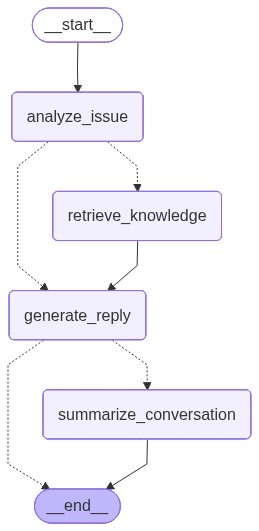

In [131]:
from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [132]:
from langchain_core.messages import HumanMessage
from pprint import pprint

result = graph.invoke({"messages": [HumanMessage(content="Hello")]})
pprint(result)

[analyze_issue] category='General' priority='Low' confidence=0.0 sentiment_score=0.0 requires_knowledge_search=False
[analyze_issue] <class '__main__.IssueExtractionResult'>
{'category': 'General',
 'issue_analyzer_confidence': 0.0,
 'messages': [HumanMessage(content='Hello', additional_kwargs={}, response_metadata={}, id='a2e189a3-f6f9-4c2c-8577-86800c5667cf'),
              AIMessage(content="Hello there! How can I assist you today? Is there something specific you'd like to talk about or a question you have? I'm here to help with whatever you need.", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 37, 'prompt_tokens': 210, 'total_tokens': 247, 'completion_time': 0.055947138, 'completion_tokens_details': None, 'prompt_time': 0.01326116, 'prompt_tokens_details': None, 'queue_time': 0.04545741, 'total_time': 0.069208298}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_f757f4b0bf', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logpr